# Extensions

The notebook uses code from `\src`, which is separated into ``models`` and ``estimation``. 

Classes in ``models`` are defined to include the methods necessary to 
a. generate synthetic data of given model parameters
b. compute the log-likelihood of synthetic data
c. parameter unconstrain, constrain, and update functions for MCMC

Classes in ``estimation`` are defined to include the methods necessary to filter for latent state given observations and to estimate model parameters from observation data. Latent state filtering methods take in models with preset parameters and data, and return the filtered latent states. Parameter estimation methods take in the model and data, and return the estimated model parameters. MCMC methods return a chain of parameter estimates.

In [56]:
# Imports
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

import sys
sys.path.insert(0, '../src')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from models.linear_gaussian import SimpleLinearGaussianSSM, LinearGaussianSSM, FixedAlphaSSM

# Filtering methods
from estimation.kalman_filter import KalmanFilter
from estimation.particle_filter import ParticleFilter

from estimation.resampling_methods import SystematicResampling, MultinomialResampling, ResidualResampling, StratifiedResampling 
# SystematicResampling will be the default for ParticleFilter

# Parameter Estimation methods
from estimation.mle_estimator import MLEEstimator
from estimation.nelder_mead import NelderMeadPMMLE
from estimation.metropolis_hastings import MetropolisHastings, BlockMetropolisHastings
from estimation.pmmh import PMMH, BlockPMMH

# Helpers
from estimation.kde import KDE
from utils import rmse, chain_ess, ess_trajectory

# Regime-switching models
from models.regime_switching_simple import SimpleRegimeSwitchingSSM, FixedAlphaRS
from estimation.rbpf import RaoBlackwellizedParticleFilter

# Other state-space models
from models.linear_t import LinearTSSM
from models.linear_ARMA import LinearARMASSM

plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Section I: Basic results (Filtering)
Quick review of basic results
1. Synthetic data generation using linear state-space model
2. Particle Filter and Kalman filter results under true parameters, RMSE, estimated log-likelihood (Particle filter) vs true log-likelihood (Kalman)

In [10]:
# true params
phi_true = 0.9
alpha_true = 1.5
sigma2_true = 0.25 # Parameterized using variance
tau2_true = 1.0 # Parameterized using variance

TRUE_PARAMS = {'phi': phi_true, 'alpha': alpha_true, 'sigma2': sigma2_true, 'tau2': tau2_true}

initial_var_fixed = 1.0

T = 200

SEED = 42

model = SimpleLinearGaussianSSM(phi=phi_true, alpha=alpha_true, sigma2=sigma2_true, tau2=tau2_true, initial_var = initial_var_fixed, seed= SEED) 
# Note that in the current implementation, when initial variance is provided, it is treated as an a priori hyperparameter and fixed throughout the simulation. It is not updated in parameter estimation
# If initial variance is not provided, the initial variance uses the default stationary distribution variance (sigma^2 / (1 - phi^2)), which is updated in parameter estimation.
print(model)

SimpleLinearGaussianSSM(phi=0.9, alpha=1.5, sigma2=0.25, tau2=1.0)


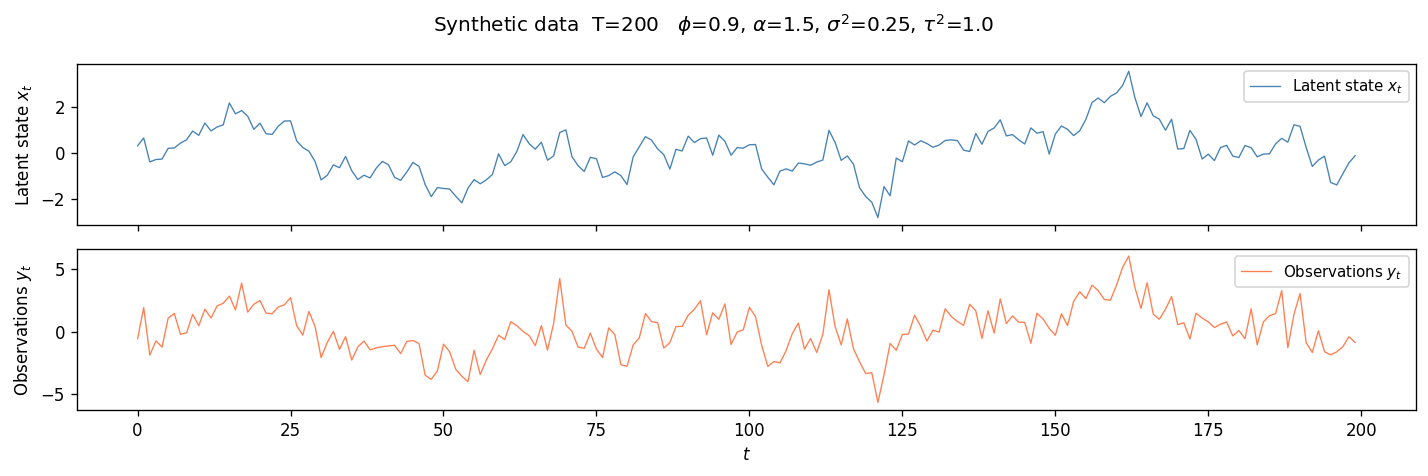

true_loglik = log p(y|x_true, theta) is the conditional log-likelihood given the known true state path: -267.41


In [11]:
# Generate Synthetic Data
states, observations, true_loglik = model.generate_data(T)

fig, axes = plt.subplots(2, 1, figsize=(12, 4), sharex=True)
axes[0].plot(states.ravel(), lw=0.8, color='steelblue', label='Latent state $x_t$')
axes[1].plot(observations.ravel(), lw=0.8, color='coral',     label='Observations $y_t$')
for ax in axes:
    ax.legend(fontsize=9)
    ax.set_ylabel(ax.get_legend().get_texts()[0].get_text())
axes[1].set_xlabel('$t$')
fig.suptitle(f'Synthetic data  T={T}   '
             rf'$\phi$={phi_true}, $\alpha$={alpha_true}, '
             rf'$\sigma^2$={sigma2_true}, $\tau^2$={tau2_true}')
plt.tight_layout()
plt.show()
print(f"true_loglik = log p(y|x_true, theta) is the conditional log-likelihood given the known true state path: {true_loglik:.2f}")


In [12]:
# Kalman filter (exact benchmark) — requires LinearGaussianSSM
kf_model = LinearGaussianSSM(
    a=np.array([[phi_true]]),
    c=np.array([[alpha_true]]),
    q=np.array([[sigma2_true]]),
    r=np.array([[tau2_true]]),
    p_0=np.array([[initial_var_fixed]])
)
kf = KalmanFilter(kf_model, observations)
kf_means, kf_covs, kf_loglik = kf.run_filter()
kf_states = kf_means.ravel()
kf_stds   = np.sqrt(kf_covs.ravel())

In [13]:
N_PARTICLES = 5000

# Particle filter
pf = ParticleFilter(model=model, N_particles=N_PARTICLES, data=observations,
                    resample_method=SystematicResampling(seed=SEED))
pf_states, p_his, w_his, rs_his, pf_loglik = pf.run_filter()
ess_traj = ess_trajectory(pf)

pf_states = pf_states.ravel()

In [14]:
kf_rmse = rmse(states.ravel(), kf_states)
pf_rmse = rmse(states.ravel(), pf_states)
print("True Log-likelihood log p(y | x_true, theta)")
print(f"Log-likelihood (true): {true_loglik:.2f}")
print()
print("Marginal Log-likelihoods log p(y | theta)")
print(f"Log-likelihood — KF (exact): {kf_loglik:.2f}")
print(f"Log-likelihood — PF estimate (N={N_PARTICLES}): {pf_loglik:.2f}")
print()
print(f"RMSE — KF: {kf_rmse:.4f}")
print(f"RMSE — PF: {pf_rmse:.4f}")

True Log-likelihood log p(y | x_true, theta)
Log-likelihood (true): -267.41

Marginal Log-likelihoods log p(y | theta)
Log-likelihood — KF (exact): -341.78
Log-likelihood — PF estimate (N=5000): -342.05

RMSE — KF: 0.4074
RMSE — PF: 0.4076


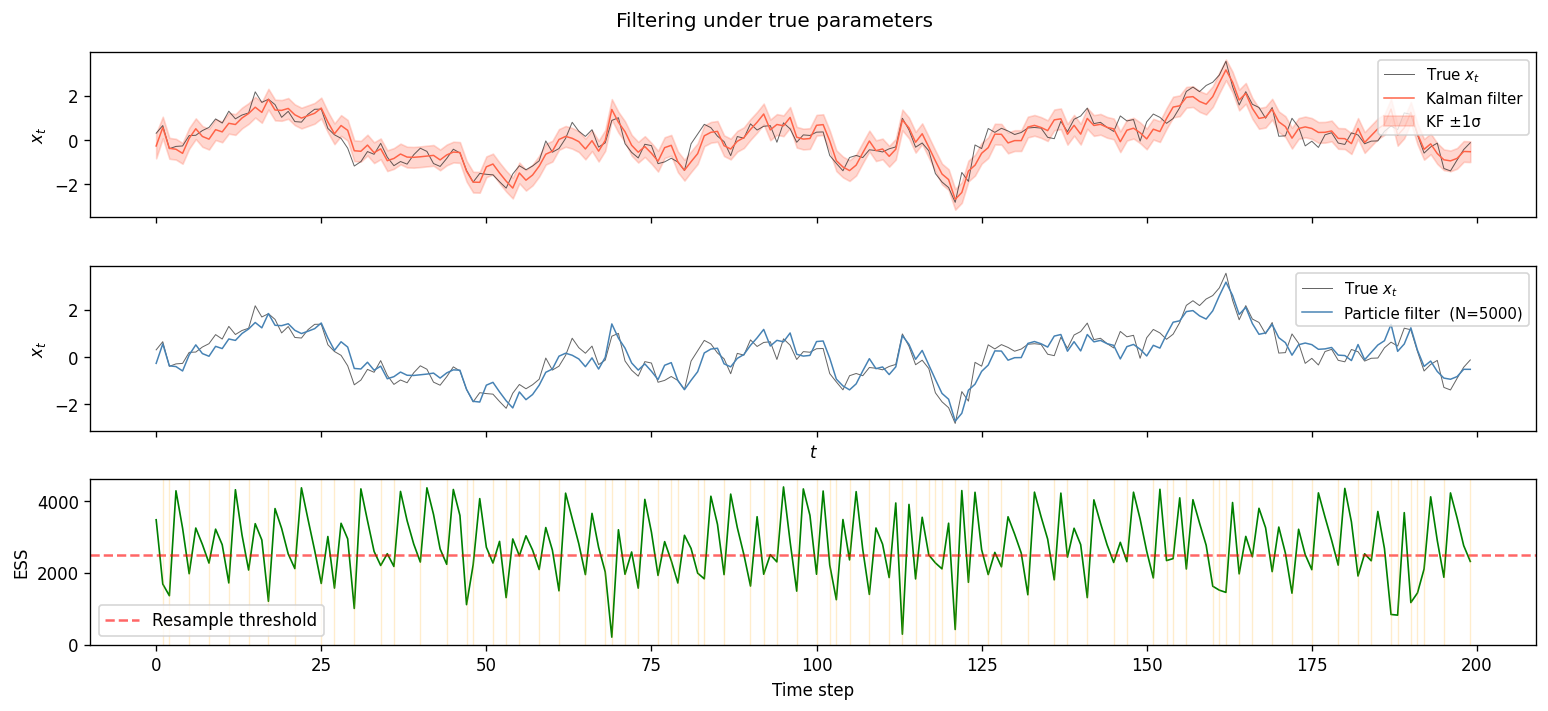

In [15]:
t_plot = np.arange(T)
fig, axes = plt.subplots(3, 1, figsize=(13, 6), sharex=True)

for ax, est, label, color in [
    (axes[0], kf_states, 'Kalman filter', 'tomato'),
    (axes[1], pf_states, f'Particle filter  (N={N_PARTICLES})', 'steelblue'),
]:
    ax.plot(states.ravel(), lw=0.6, color='black', alpha=0.6, label='True $x_t$')
    ax.plot(est, lw=0.9, color=color, label=label)
    if color == 'tomato':                        # add KF ±1σ band
        ax.fill_between(t_plot, kf_states - kf_stds, kf_states + kf_stds,
                        alpha=0.25, color=color, label='KF ±1σ')
    ax.legend(fontsize=9, loc='upper right')
    ax.set_ylabel('$x_t$')

axes[1].set_xlabel('$t$')
fig.suptitle('Filtering under true parameters')

axes[2].plot(ess_traj, color='green', lw=1)
axes[2].axhline(pf.resample_threshold * pf.N_particles, color='red',
                linestyle='--', alpha=0.6, label='Resample threshold')
for s in [i for i, r in enumerate(rs_his) if r]:
    axes[2].axvline(s, color='orange', alpha=0.2, lw=0.8)
axes[2].set_ylabel('ESS')
axes[2].set_xlabel('Time step')
axes[2].legend()

plt.tight_layout()
plt.show()


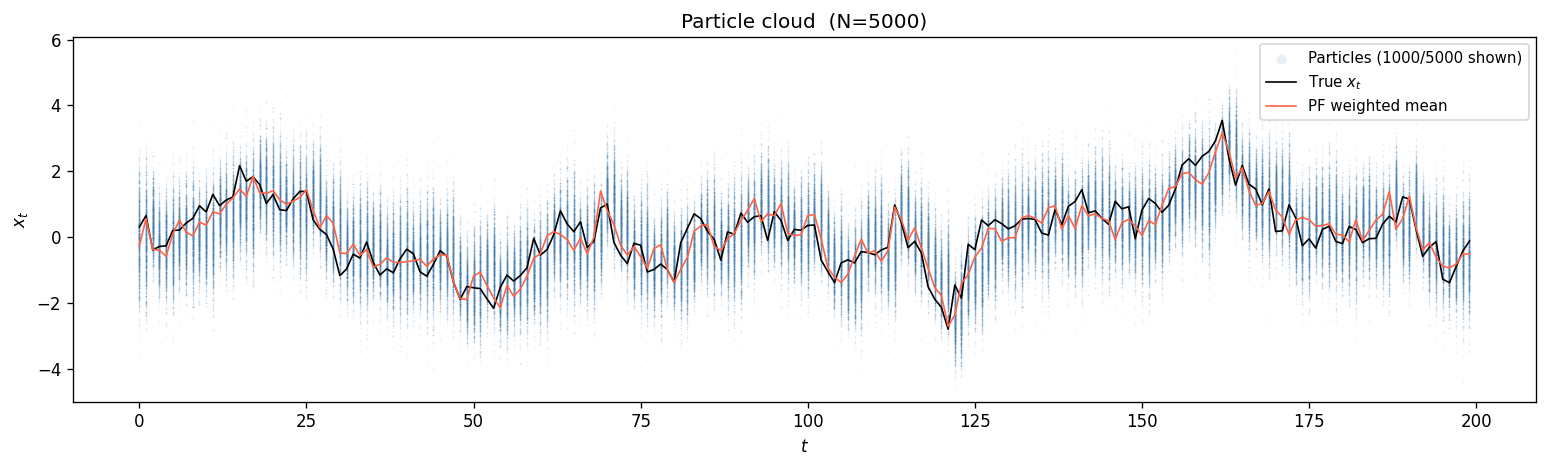

In [16]:
# Plot particle cloud (marginal filtering distribution at each timestep)
N_SHOW  = 1000   # particles sampled per timestep (out of N_PARTICLES)
rng_vis = np.random.default_rng(0)
t_plot  = np.arange(T)

t_scatter = np.repeat(t_plot, N_SHOW)
x_scatter = np.concatenate([
    p_his[t][rng_vis.choice(N_PARTICLES, N_SHOW, replace=False)]
    for t in t_plot
])

fig, ax = plt.subplots(figsize=(13, 4))
ax.scatter(t_scatter, x_scatter, s=1, alpha=0.12, color='steelblue',
           linewidths=0, label=f'Particles ({N_SHOW}/{N_PARTICLES} shown)')
ax.plot(states.ravel(), lw=1.0, color='black',  label='True $x_t$')
ax.plot(pf_states,      lw=1.0, color='tomato', label='PF weighted mean')
ax.set_xlabel('$t$')
ax.set_ylabel('$x_t$')
ax.legend(fontsize=9, loc='upper right', markerscale=6)
ax.set_title(f'Particle cloud  (N={N_PARTICLES})')
plt.tight_layout()
plt.show()

## Section II: Particle Filter More Detailed Results
Here, using true parameter values
1. Effect of number of particles on RMSE and log-likelihood estimation variability (Note: previous results showed that standard deviaition of log likelihood is proportional to 1/sqrt(N_particles))
2. Noise sensitivity: effect of σ and τ on filtering accuracy (RMSE of filtered latent state and estimated log-likelihood of observation given parameters), compared with Kalman filter (Note: previous notebook showed that Particle Filter and Kalman Filter reacted similarily to noise sensitivity)
3. Effect of Resampling Method Choice
4. Conclusion: optimal setup for Particle Filter (use in PMMH)

### 1. Effect of Number of Particles

Estimated runtime: 5~15 min

In [17]:
N_values = [25, 50, 100, 250, 500, 1000, 2500, 5000, 10000]
N_reps   = 10

rmse_by_N   = {n: [] for n in N_values}
loglik_by_N = {n: [] for n in N_values}

for N_p in N_values:
    for rep in range(N_reps):
        pf_n = ParticleFilter(model=model, N_particles=N_p, data=observations,
                              resample_method=SystematicResampling(seed=rep))
        pf_latent, _, _, _, ll_n = pf_n.run_filter()
        rmse_by_N[N_p].append(rmse(states.ravel(), pf_latent))
        loglik_by_N[N_p].append(ll_n)
    print(f"N={N_p:6d}  RMSE={np.mean(rmse_by_N[N_p]):.4f} ± {np.std(rmse_by_N[N_p]):.4f}"
          f"  loglik={np.mean(loglik_by_N[N_p]):.2f} ± {np.std(loglik_by_N[N_p]):.2f}")

N=    25  RMSE=0.4314 ± 0.0051  loglik=-345.74 ± 3.24
N=    50  RMSE=0.4165 ± 0.0101  loglik=-343.96 ± 2.28
N=   100  RMSE=0.4135 ± 0.0060  loglik=-342.75 ± 1.04
N=   250  RMSE=0.4079 ± 0.0031  loglik=-341.98 ± 1.13
N=   500  RMSE=0.4086 ± 0.0017  loglik=-342.12 ± 0.52
N=  1000  RMSE=0.4072 ± 0.0010  loglik=-341.88 ± 0.35
N=  2500  RMSE=0.4072 ± 0.0008  loglik=-341.86 ± 0.26
N=  5000  RMSE=0.4073 ± 0.0005  loglik=-341.79 ± 0.30
N= 10000  RMSE=0.4075 ± 0.0006  loglik=-341.79 ± 0.10


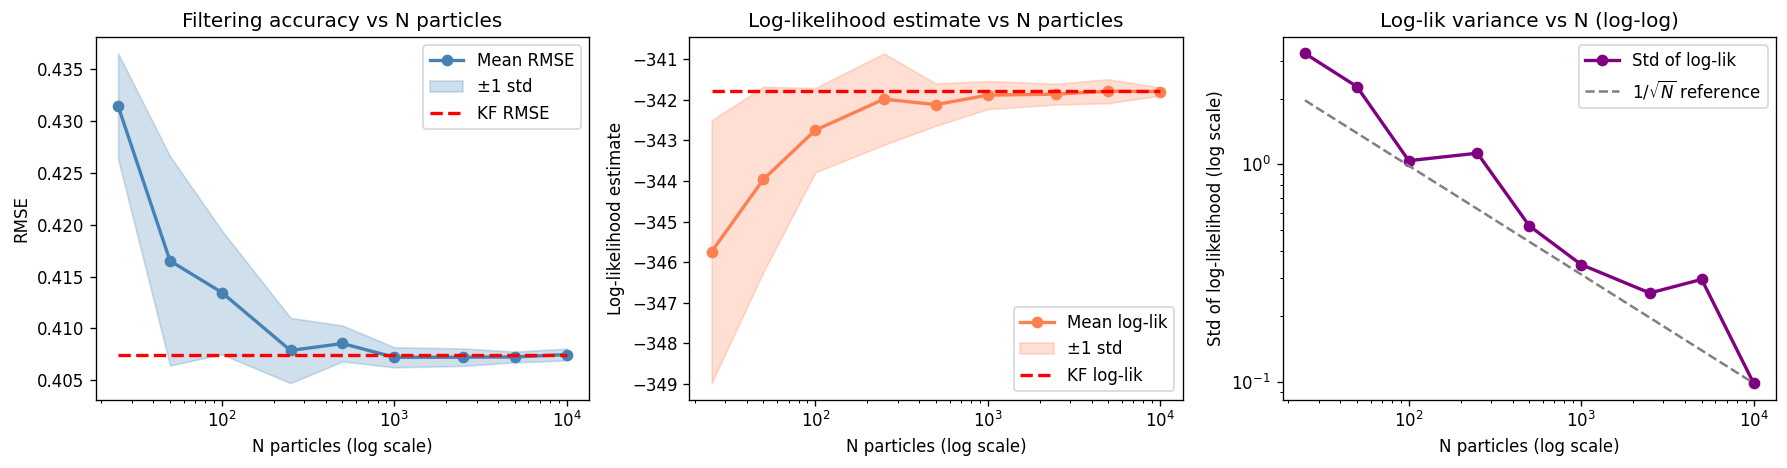

In [19]:
# Reference RMSE and log likelihood from Kalman Filter are stored in kf_rmse and kf_loglik
rmse_mean   = np.array([np.mean(rmse_by_N[n]) for n in N_values])
rmse_std    = np.array([np.std(rmse_by_N[n]) for n in N_values])
loglik_mean = np.array([np.mean(loglik_by_N[n]) for n in N_values])
loglik_std  = np.array([np.std(loglik_by_N[n]) for n in N_values])

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# ── RMSE mean ± 1 std ──────────────────────────────────────────────────────
axes[0].semilogx(N_values, rmse_mean, 'o-', color='steelblue', lw=2, label='Mean RMSE')
axes[0].fill_between(N_values, rmse_mean - rmse_std, rmse_mean + rmse_std,
                     alpha=0.25, color='steelblue', label='±1 std')
axes[0].semilogx(N_values, kf_rmse * np.ones(len(N_values)), '--', color = 'red', lw=2, label = 'KF RMSE')
axes[0].set_xlabel('N particles (log scale)')
axes[0].set_ylabel('RMSE')
axes[0].set_title('Filtering accuracy vs N particles')
axes[0].legend()

# ── log-likelihood mean ± 1 std ────────────────────────────────────────────
axes[1].semilogx(N_values, loglik_mean, 'o-', color='coral', lw=2, label='Mean log-lik')
axes[1].fill_between(N_values, loglik_mean - loglik_std, loglik_mean + loglik_std,
                     alpha=0.25, color='coral', label='±1 std')
# plot true log-likelihood of data as a constant line
axes[1].semilogx(N_values, kf_loglik * np.ones(len(N_values)), '--', color='red', lw=2, label='KF log-lik')
axes[1].set_xlabel('N particles (log scale)')
axes[1].set_ylabel('Log-likelihood estimate')
axes[1].set_title('Log-likelihood estimate vs N particles')
axes[1].legend()

# ── log-likelihood std on log-log (should scale as 1/sqrt(N)) ─────────────
axes[2].loglog(N_values, loglik_std, 'o-', color='purple', lw=2, label='Std of log-lik')
# reference 1/sqrt(N) line anchored at the largest N
ref_scale = loglik_std[-1] * np.sqrt(N_values[-1])
ref_line  = ref_scale / np.sqrt(N_values)
axes[2].loglog(N_values, ref_line, '--', color='gray', lw=1.5, label='$1/\\sqrt{N}$ reference')
axes[2].set_xlabel('N particles (log scale)')
axes[2].set_ylabel('Std of log-likelihood (log scale)')
axes[2].set_title('Log-lik variance vs N (log-log)')
axes[2].legend()

plt.tight_layout()
plt.show()

We see that RMSE and log-likelihood from Particle Filter estimates converge to Kalman Filter values as $N \to \infty$. The standard deviation of PF log-likelihood estimate is proportional to $1/\sqrt{N}$, as expected.

### 2. Noise Sensitivity

In [20]:
# Sweep σ so r = σ²/τ² ∈ [0.01, 9]; repeat for several τ values and plot as separate lines.
phi_r    = 0.9
alpha_r  = 1.0
N_r      = 200 # Number of particles
T_r      = 200
n_reps_r = 10  # Number of repeated trials for data generation and filtering

tau_r_vals   = [0.5, 1.0, 2.0, 4.0]
sigma_r_vals = np.logspace(-1, np.log10(3.0), 5)   # sigma 0.1 … 3.0

results_by_tau = {}
rng_r = np.random.default_rng(77)

for tau_r in tau_r_vals:
    ratio_vals       = sigma_r_vals ** 2 / tau_r ** 2
    pf_rmse_mean     = np.zeros(len(sigma_r_vals))
    pf_rmse_std      = np.zeros(len(sigma_r_vals))
    kf_rmse_mean     = np.zeros(len(sigma_r_vals))
    pf_loglik_mean   = np.zeros(len(sigma_r_vals))
    pf_loglik_std    = np.zeros(len(sigma_r_vals))
    kf_loglik_mean   = np.zeros(len(sigma_r_vals))
    loglik_bias_mean = np.zeros(len(sigma_r_vals))
    loglik_bias_std  = np.zeros(len(sigma_r_vals))

    for i, sigma_r in enumerate(sigma_r_vals):
        pf_rmse_i   = []
        kf_rmse_i   = []
        pf_loglik_i = []
        kf_loglik_i = []

        for rep in range(n_reps_r):
            seed_r = int(rng_r.integers(0, 10**6))
            m_r = SimpleLinearGaussianSSM(phi=phi_r, alpha=alpha_r,
                                          sigma2=sigma_r**2, tau2=tau_r**2,
                                          initial_var=initial_var_fixed, seed=seed_r)
            s_r, o_r, _ = m_r.generate_data(T_r)
            obs_r  = o_r[:, 0]
            true_r = s_r[:, 0]

            pf_r = ParticleFilter(model=m_r, N_particles=N_r, data=obs_r,
                                  resample_method=SystematicResampling(seed=rep))
            pf_r_latent, _, _, _, pf_r_loglik = pf_r.run_filter()
            pf_rmse_i.append(rmse(true_r, pf_r_latent))
            pf_loglik_i.append(pf_r_loglik)

            kf_m = LinearGaussianSSM(
                a=np.array([[phi_r]]),
                c=np.array([[alpha_r]]),
                q=np.array([[sigma_r ** 2]]),
                r=np.array([[tau_r ** 2]]),
                p_0=np.array([[initial_var_fixed]])
            )
            kf_r = KalmanFilter(model=kf_m, data=obs_r)
            filt_m, _, kf_r_loglik = kf_r.run_filter()
            kf_rmse_i.append(rmse(true_r, filt_m[:, 0]))
            kf_loglik_i.append(kf_r_loglik)

        bias_i = [p - k for p, k in zip(pf_loglik_i, kf_loglik_i)]

        pf_rmse_mean[i]     = np.mean(pf_rmse_i)
        pf_rmse_std[i]      = np.std(pf_rmse_i)
        kf_rmse_mean[i]     = np.mean(kf_rmse_i)
        pf_loglik_mean[i]   = np.mean(pf_loglik_i)
        pf_loglik_std[i]    = np.std(pf_loglik_i)
        kf_loglik_mean[i]   = np.mean(kf_loglik_i)
        loglik_bias_mean[i] = np.mean(bias_i)
        loglik_bias_std[i]  = np.std(bias_i)

    results_by_tau[tau_r] = dict(
        ratio=ratio_vals,
        pf_rmse_mean=pf_rmse_mean,
        pf_rmse_std=pf_rmse_std,
        kf_rmse_mean=kf_rmse_mean,
        pf_loglik_mean=pf_loglik_mean,
        pf_loglik_std=pf_loglik_std,
        kf_loglik_mean=kf_loglik_mean,
        loglik_bias_mean=loglik_bias_mean,
        loglik_bias_std=loglik_bias_std,
    )
    print(f"\u03c4\u00b2={tau_r**2:.2f}  done")


τ²=0.25  done
τ²=1.00  done
τ²=4.00  done
τ²=16.00  done


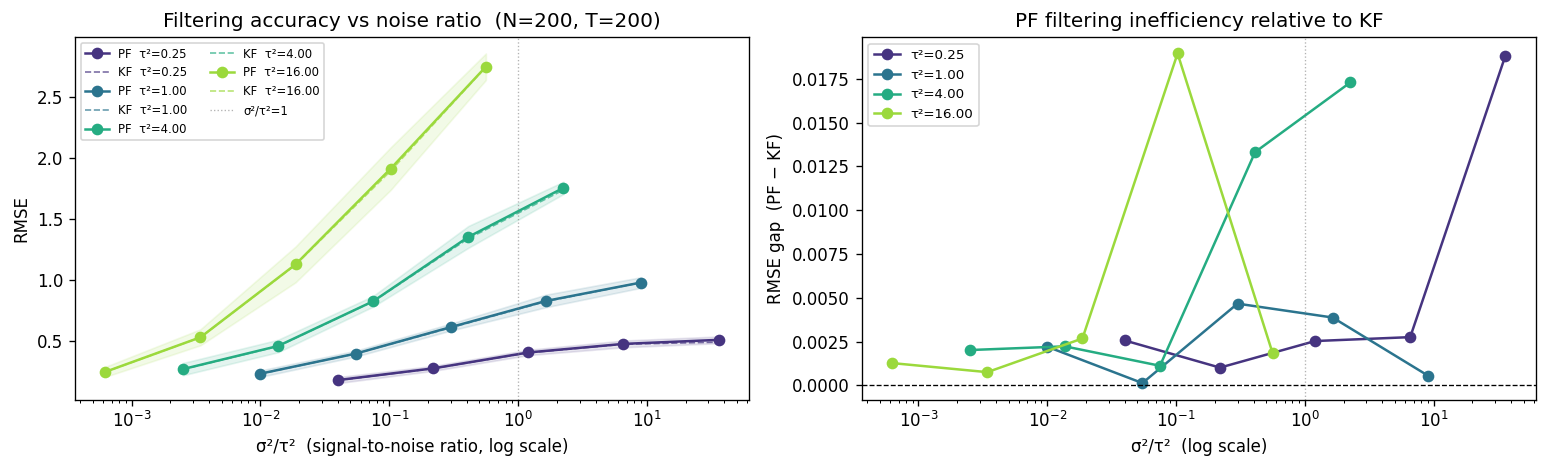

In [41]:
colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(tau_r_vals)))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for tau_r, col in zip(tau_r_vals, colors):
    r   = results_by_tau[tau_r]
    lbl = f'τ²={tau_r**2:.2f}'

    # PF mean ± 1 std
    axes[0].semilogx(r['ratio'], r['pf_rmse_mean'], 'o-', color=col, lw=1.5, label=f'PF  {lbl}')
    axes[0].fill_between(r['ratio'],
                         r['pf_rmse_mean'] - r['pf_rmse_std'],
                         r['pf_rmse_mean'] + r['pf_rmse_std'],
                         alpha=0.12, color=col)
    # KF as dashed reference
    axes[0].semilogx(r['ratio'], r['kf_rmse_mean'], '--', color=col, lw=1.0, alpha=0.7,
                     label=f'KF  {lbl}')

    # RMSE gap: PF - KF (filtering inefficiency)
    gap = r['pf_rmse_mean'] - r['kf_rmse_mean']
    axes[1].semilogx(r['ratio'], gap, 'o-', color=col, lw=1.5, label=lbl)

axes[0].axvline(1.0, color='grey', lw=0.8, ls=':', alpha=0.6, label='σ²/τ²=1')
axes[0].set_xlabel('σ²/τ²  (signal-to-noise ratio, log scale)')
axes[0].set_ylabel('RMSE')
axes[0].set_title(f'Filtering accuracy vs noise ratio  (N={N_r}, T={T_r})')
axes[0].legend(fontsize=7, ncol=2)

axes[1].axhline(0,   color='black', lw=0.8, ls='--')
axes[1].axvline(1.0, color='grey',  lw=0.8, ls=':', alpha=0.6)
axes[1].set_xlabel('σ²/τ²  (log scale)')
axes[1].set_ylabel('RMSE gap  (PF − KF)')
axes[1].set_title('PF filtering inefficiency relative to KF')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()


In [21]:
# Print report: log-likelihood bias (PF − KF) across noise regimes
print(f"Log-likelihood bias  E[PF − KF]   N_particles={N_r}, T={T_r}, reps={n_reps_r}\n")
step = max(1, len(sigma_r_vals) // 8)

for tau_r in tau_r_vals:
    r = results_by_tau[tau_r]
    print(f"\u03c4\u00b2 = {tau_r**2:.2f}")
    print(f"  {'\u03c3\u00b2/\u03c4\u00b2':>8}  {'KF loglik':>10}  {'PF loglik':>10}  {'Bias':>8}  {'PF std':>7}")
    print(f"  {'-' * 50}")
    for j in range(0, len(r['ratio']), step):
        print(f"  {r['ratio'][j]:8.3f}  {r['kf_loglik_mean'][j]:10.2f}  "
              f"{r['pf_loglik_mean'][j]:10.2f}  {r['loglik_bias_mean'][j]:8.2f}  "
              f"{r['pf_loglik_std'][j]:7.2f}")
    print()


Log-likelihood bias  E[PF − KF]   N_particles=200, T=200, reps=10

τ² = 0.25
     σ²/τ²   KF loglik   PF loglik      Bias   PF std
  --------------------------------------------------
     0.040     -161.57     -161.82     -0.25     7.54
     0.219     -188.02     -188.04     -0.02    14.09
     1.200     -247.63     -248.83     -1.20     9.62
     6.573     -355.68     -357.76     -2.07     9.53
    36.000     -510.40     -518.47     -8.06    10.96

τ² = 1.00
     σ²/τ²   KF loglik   PF loglik      Bias   PF std
  --------------------------------------------------
     0.010     -290.53     -290.49      0.05    11.24
     0.055     -301.11     -301.09      0.02     6.23
     0.300     -325.12     -326.18     -1.07     9.20
     1.643     -394.14     -394.94     -0.80     7.39
     9.000     -512.23     -513.78     -1.55    10.78

τ² = 4.00
     σ²/τ²   KF loglik   PF loglik      Bias   PF std
  --------------------------------------------------
     0.003     -416.66     -416.69     -

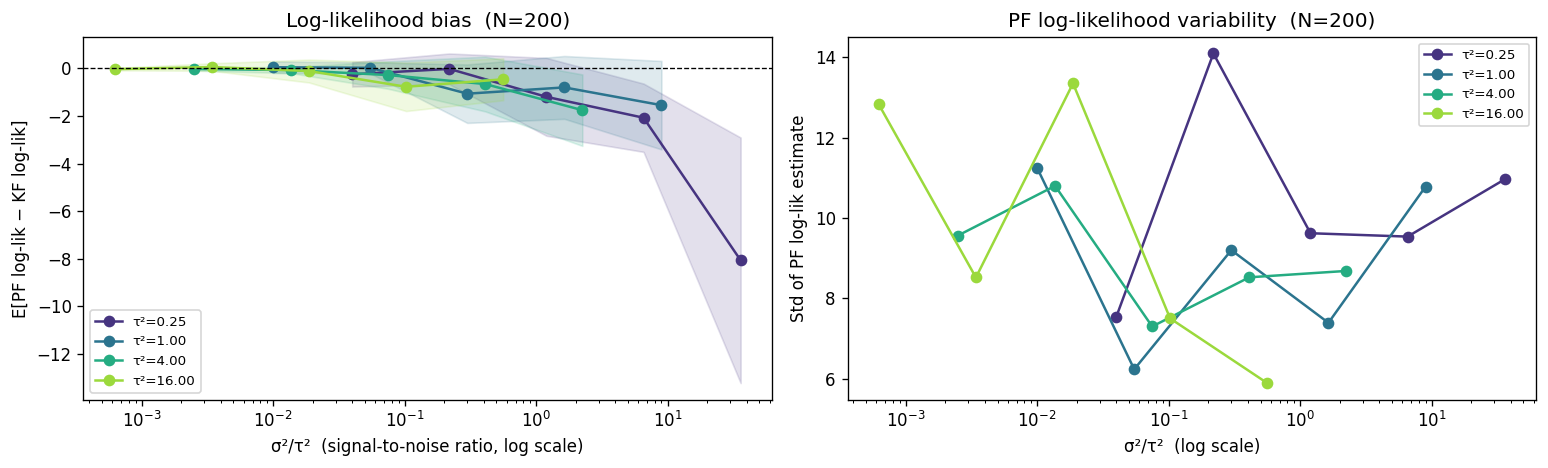

In [22]:
colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(tau_r_vals)))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for tau_r, col in zip(tau_r_vals, colors):
    r = results_by_tau[tau_r]
    lbl = f'\u03c4\u00b2={tau_r**2:.2f}'

    # Bias (mean ± 1 std)
    axes[0].semilogx(r['ratio'], r['loglik_bias_mean'], 'o-', color=col, lw=1.5, label=lbl)
    axes[0].fill_between(r['ratio'],
                         r['loglik_bias_mean'] - r['loglik_bias_std'],
                         r['loglik_bias_mean'] + r['loglik_bias_std'],
                         alpha=0.15, color=col)

    # PF log-lik std
    axes[1].semilogx(r['ratio'], r['pf_loglik_std'], 'o-', color=col, lw=1.5, label=lbl)

axes[0].axhline(0, color='black', lw=0.8, ls='--')
axes[0].set_xlabel('\u03c3\u00b2/\u03c4\u00b2  (signal-to-noise ratio, log scale)')
axes[0].set_ylabel('E[PF log-lik \u2212 KF log-lik]')
axes[0].set_title(f'Log-likelihood bias  (N={N_r})')
axes[0].legend(fontsize=8)

axes[1].set_xlabel('\u03c3\u00b2/\u03c4\u00b2  (log scale)')
axes[1].set_ylabel('Std of PF log-lik estimate')
axes[1].set_title(f'PF log-likelihood variability  (N={N_r})')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()


### 3. Effect of Resampling Method Choice

In [25]:
resamplers = {
    'Systematic' : SystematicResampling,
    'Stratified' : StratifiedResampling,
    'Residual'   : ResidualResampling,
    'Multinomial': MultinomialResampling,
}

N_rs   = 30
T_rs   = T
N_part = 500

rmse_rs   = {k: [] for k in resamplers}
loglik_rs = {k: [] for k in resamplers}

for seed in range(N_rs):
    m = SimpleLinearGaussianSSM(phi=0.9, alpha=1.0, sigma2=0.25, tau2=1.0, initial_var = initial_var_fixed, seed=seed)
    s, o, _ = m.generate_data(T_rs)
    for name, cls in resamplers.items():
        pf_ = ParticleFilter(model=m, N_particles=N_part, data=o[:, 0],
                             resample_method=cls(seed=seed + 2000), seed=seed + 3000)
        pf_states, ph_, wh_, _, ll = pf_.run_filter(verbose=False)
        rmse_rs[name].append(rmse(s[:, 0], pf_states))
        loglik_rs[name].append(ll)

In [26]:
results = {
    name: (np.mean(rmse_rs[name]), np.std(rmse_rs[name]),
           np.mean(loglik_rs[name]), np.std(loglik_rs[name]))
    for name in resamplers
}

best = {
    0: min(results, key=lambda x: results[x][0]),  # lowest RMSE mean
    1: min(results, key=lambda x: results[x][1]),  # lowest RMSE std
    2: max(results, key=lambda x: results[x][2]),  # highest loglik mean
    3: min(results, key=lambda x: results[x][3]),  # lowest loglik std
}

def star(name, col):
    return '★' if best[col] == name else ' '

print(f"{'Method':<12}  {'RMSE mean':>10}  {'RMSE std':>9}  {'loglik mean':>12}  {'loglik std':>10}")
print('-' * 60)
for name, (rm, rs, lm, ls) in results.items():
    print(f"{name:<12}  {rm:>9.4f}{star(name,0)}  {rs:>8.4f}{star(name,1)}  "
          f"{lm:>11.2f}{star(name,2)}  {ls:>9.2f}{star(name,3)}")

Method         RMSE mean   RMSE std   loglik mean  loglik std
------------------------------------------------------------
Systematic       0.5843     0.0542       -328.69★       8.35 
Stratified       0.5839★    0.0534★      -329.02        8.31 
Residual         0.5841     0.0542       -329.18        8.21 
Multinomial      0.5844     0.0552       -328.99        8.20★


/var/folders/6t/j_420_511zsftkrvyzgx57l80000gn/T/ipykernel_73865/3169042032.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot([rmse_rs[n] for n in names], labels=names)
/var/folders/6t/j_420_511zsftkrvyzgx57l80000gn/T/ipykernel_73865/3169042032.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([loglik_rs[n] for n in names], labels=names)


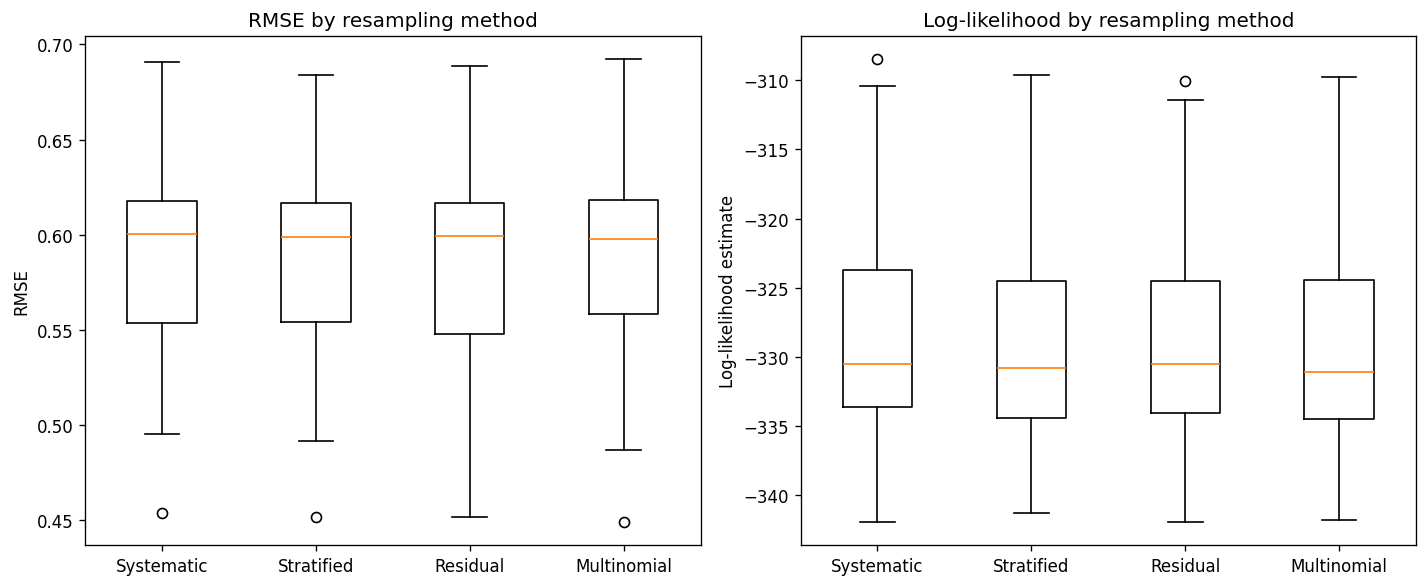

In [27]:
names = list(resamplers.keys())

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].boxplot([rmse_rs[n] for n in names], labels=names)
axes[0].set_ylabel('RMSE')
axes[0].set_title('RMSE by resampling method')

axes[1].boxplot([loglik_rs[n] for n in names], labels=names)
axes[1].set_ylabel('Log-likelihood estimate')
axes[1].set_title('Log-likelihood by resampling method')

plt.tight_layout()
plt.show()

### 4. Conclusion

Choose `Systematicmpling` or `StratifiedResampling` as resampling method. For current synthetic data, around N_particles = 1000 should be sufficient.

## Section III. Basic Results (Estimation)
1. Parameter Log-Likelihood Ridge for (alpha, sigma2) with other parameters fixed to true values, plot log-likelihood surface
2. Parameter estimation using MLE (alpha fixed at true alpha)
3. Parameter estimation using MH (alpha fixed at true alpha)
4. Parameter estimation using Nelder-Mead and particle filter likelihood estimate
5. Comparison table summary of parameter estimation methods
6. (Optional) Plot individual scatterplot of estimated parameters (in pairs) on log-likelihood surfaces for parameter estimation (with other parameters fixed to true value)


### 1. Examining Log-Likelihood Surface and Scale Ambiguity

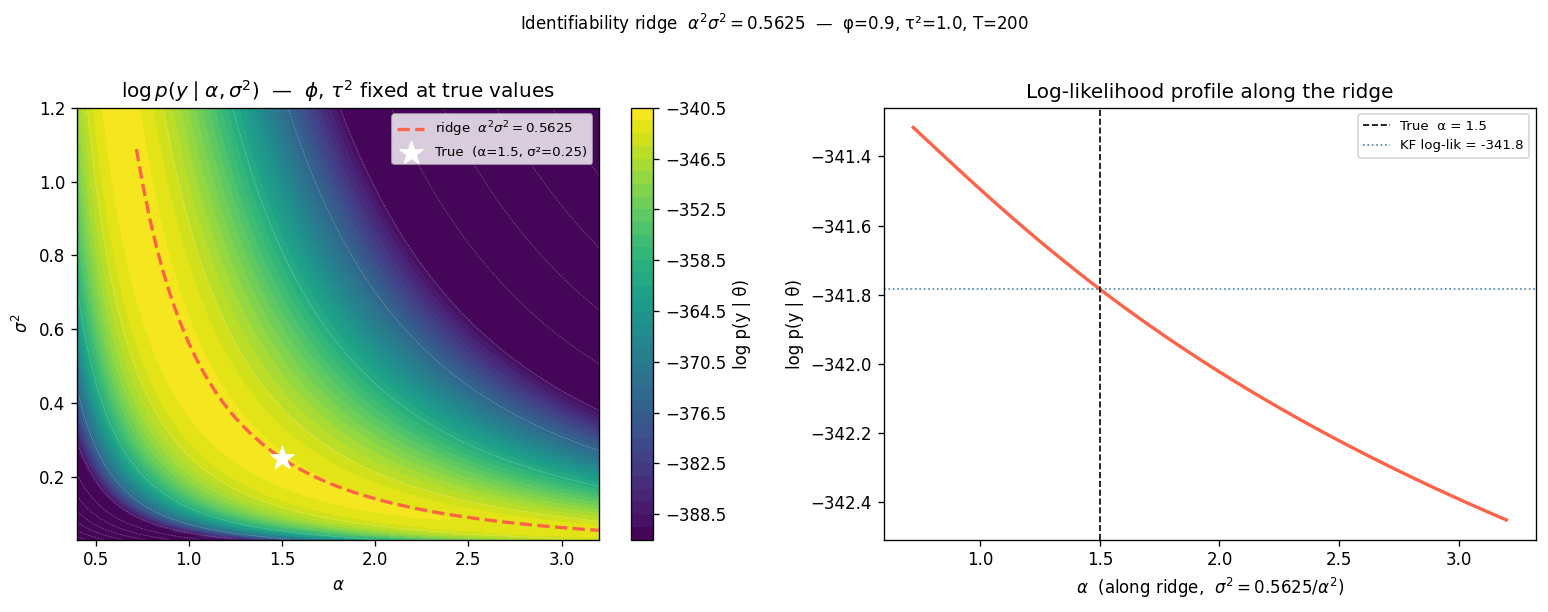

In [28]:
# Log-Likelihood Ridge Plot
# 2D slice of log p(y | alpha, sigma2) with phi and tau2 fixed at true values.
# The ridge lies along alpha^2 * sigma2 = alpha_true^2 * sigma2_true (scale ambiguity).

obs_1d = observations.ravel()

alpha_grid  = np.linspace(0.4, 3.2, 80)
sigma2_grid = np.linspace(0.03, 1.2, 80)

LL = np.full((len(sigma2_grid), len(alpha_grid)), np.nan)
for j, a in enumerate(alpha_grid):
    for i, s2 in enumerate(sigma2_grid):
        try:
            model.update_params([phi_true, a, s2, tau2_true])
            LL[i, j] = model.log_likelihood(obs_1d)
        except Exception:
            pass
model.update_params([phi_true, alpha_true, sigma2_true, tau2_true])  # restore

# Ridge curve: alpha^2 * sigma2 = C (scale-ambiguity constraint)
C_ridge      = alpha_true**2 * sigma2_true        # = 1.5^2 * 0.25 = 0.5625
ridge_sigma2 = C_ridge / alpha_grid**2
ridge_mask   = (ridge_sigma2 >= sigma2_grid.min()) & (ridge_sigma2 <= sigma2_grid.max())

# Log-likelihood evaluated exactly along the ridge
ridge_ll = []
for a in alpha_grid:
    s2 = C_ridge / a**2
    if s2 < sigma2_grid.min() or s2 > sigma2_grid.max():
        ridge_ll.append(np.nan)
        continue
    try:
        model.update_params([phi_true, a, s2, tau2_true])
        ridge_ll.append(model.log_likelihood(obs_1d))
    except Exception:
        ridge_ll.append(np.nan)
model.update_params([phi_true, alpha_true, sigma2_true, tau2_true])  # restore
ridge_ll = np.array(ridge_ll)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── left: filled contour heatmap ──────────────────────────────────────────
vmax = np.nanmax(LL)
vmin = vmax - 50
im = axes[0].contourf(alpha_grid, sigma2_grid, np.clip(LL, vmin, vmax),
                      levels=40, cmap='viridis')
axes[0].contour(alpha_grid, sigma2_grid, LL, levels=12,
                colors='white', linewidths=0.35, alpha=0.35)
fig.colorbar(im, ax=axes[0], label='log p(y | θ)')
axes[0].plot(alpha_grid[ridge_mask], ridge_sigma2[ridge_mask],
             '--', color='tomato', lw=2,
             label=r'ridge  $\alpha^2 \sigma^2 = %.4f$' % C_ridge)
axes[0].scatter([alpha_true], [sigma2_true],
                color='white', marker='*', s=200, zorder=5,
                label=f'True  (α={alpha_true}, σ²={sigma2_true})')
axes[0].set_xlabel(r'$\alpha$')
axes[0].set_ylabel(r'$\sigma^2$')
axes[0].set_title(r'$\log p(y \mid \alpha, \sigma^2)$  —  $\phi$, $\tau^2$ fixed at true values')
axes[0].legend(fontsize=8, loc='upper right')

# ── right: 1-D profile along the ridge ───────────────────────────────────
axes[1].plot(alpha_grid, ridge_ll, color='tomato', lw=2)
axes[1].axvline(alpha_true, ls='--', color='black', lw=1,
                label=f'True  α = {alpha_true}')
axes[1].axhline(kf_loglik, ls=':', color='steelblue', lw=1,
                label=f'KF log-lik = {kf_loglik:.1f}')
axes[1].set_xlabel(r'$\alpha$  (along ridge,  $\sigma^2 = {%.4f}/\alpha^2$)' % C_ridge)
axes[1].set_ylabel('log p(y | θ)')
axes[1].set_title('Log-likelihood profile along the ridge')
axes[1].legend(fontsize=8)

plt.suptitle(
    rf'Identifiability ridge  $\alpha^2 \sigma^2 = {C_ridge:.4f}$'
    rf'  —  φ={phi_true}, τ²={tau2_true}, T={T}',
    fontsize=10, y=1.01
)
plt.tight_layout()
plt.show()


### 2.Parameter Estimation with MLE

In [32]:
# MLE with alpha fixed — 3-param model: (phi, sigma2, tau2)
# Uses the exact Kalman log-likelihood, so results are deterministic.

model_mle = FixedAlphaSSM(
    alpha_fixed=alpha_true,
    phi=phi_true, sigma2=sigma2_true, tau2=tau2_true,
    initial_var=initial_var_fixed, seed=SEED,
)

mle = MLEEstimator(
    model=model_mle, # Calls model_mle.log_likelihood() which uses Kalman filter internally
    data=observations,
    method='L-BFGS-B',
    n_restarts=3,
    restart_std=0.5,
    seed=0,
)
mle_result = mle.fit()
mle.compute_std_errors()
print(mle_result.summary())


Restart 0/3 best val: 341.277620077348
Restart 1/3 best val: 341.277620077348
Restart 2/3 best val: 341.277620077348
MLEEstimator.fit  0.093s
MLEResult  loglik=-341.2776  converged  n_evals=64
  CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH

  Parameter             Estimate     Std error
  --------------------------------------------
  phi                   0.885722      0.046616
  sigma2                0.250958      0.086108
  tau2                  0.865117      0.180643


### 3. Parameter Estimation with Metropolis-Hastings

In [33]:
# Fixing alpha breaks the alpha·sqrt(sigma2) ridge and makes the posterior
# identifiable.  Parameters are now (phi, sigma2, tau2) with variance params.

def log_prior_fixed_alpha(theta_con):
    """Independent priors on (phi, sigma2, tau2) with alpha fixed."""
    phi, sigma2, tau2 = theta_con
    if phi <= -1 or phi >= 1:
        return -np.inf
    if sigma2 <= 0 or tau2 <= 0:
        return -np.inf
    return sum([
        np.log(2) - np.log(1 + phi ** 2),     # Cauchy(0,1) on (-1,1) for phi
        -np.log(sigma2),                      # HalfCauchy(0,1) ∝ 1/sigma2
        -np.log(tau2),                        # HalfCauchy(0,1) ∝ 1/tau2
    ])


N_ITER_FA  = 3000
BURN_IN_FA = 500

model_fa  = FixedAlphaSSM(alpha_fixed = alpha_true, phi = phi_true, sigma2 = sigma2_true, tau2 = tau2_true, initial_var = initial_var_fixed, seed=5)
theta0_fa = model_fa.unconstrain_params(
    [phi_true, sigma2_true, tau2_true]
)

mh_fa = MetropolisHastings(
    model_fa, observations,
    n_iter=N_ITER_FA,
    step_sizes=np.array([0.06, 0.12, 0.12]),
    theta0=theta0_fa,
    log_prior=log_prior_fixed_alpha,
    seed=3,
)
print(mh_fa)


MetropolisHastings(model=SimpleLinearGaussianSSM(phi=0.9, alpha=1.5, sigma2=0.25, tau2=1.0), n_iter=3000)


In [34]:
print("Running MH with fixed alpha=1.0 (3000 iterations) ...")
chain_fa, ll_fa, acc_fa = mh_fa.run()

constrained_fa = model_fa.constrain_chain(chain_fa[BURN_IN_FA:])

mh_fa.summary(burn=BURN_IN_FA)

names_fa   = list(model_fa.params_dict.keys())
true_fa    = [TRUE_PARAMS[p] for p in names_fa]


Running MH with fixed alpha=1.0 (3000 iterations) ...
MetropolisHastings.run  1.555s
param              mean        std
----------------------------------
phi              0.8738     0.0492
sigma2           0.2953     0.1011
tau2             0.8068     0.1813

Acceptance rate: 0.651  (burn=500)


In [35]:
cols = {
    "param": 8,
    "true": 10,
    "mean": 12,
    "std": 12,
    "adj": 16,
    "ess": 10,
}

header = (
    f"{'Param':<{cols['param']}}"
    f"{'True':>{cols['true']}}"
    f"{'Post mean':>{cols['mean']}}"
    f"{'Post std':>{cols['std']}}"
    f"{'Post std (adj)':>{cols['adj']}}"
    f"{'ESS':>{cols['ess']}}"
)

print("\n" + header)
print("─" * len(header))

for k, name in enumerate(names_fa):
    samp = constrained_fa[:, k]
    ess = chain_ess(samp)
    adj_std = samp.std() * np.sqrt(len(samp) / ess) if ess > 0 else np.nan

    row = (
        f"{name:<{cols['param']}}"
        f"{true_fa[k]:>{cols['true']}.4f}"
        f"{samp.mean():>{cols['mean']}.4f}"
        f"{samp.std():>{cols['std']}.4f}"
        f"{adj_std:>{cols['adj']}.4f}"
        f"{ess:>{cols['ess']}.1f}"
    )
    print(row)


Param         True   Post mean    Post std  Post std (adj)       ESS
────────────────────────────────────────────────────────────────────
phi         0.9000      0.8738      0.0492          0.3892      39.9
sigma2      0.2500      0.2953      0.1011          0.8957      31.9
tau2        1.0000      0.8068      0.1813          1.3810      43.1


Post std (adj) are posterior standard deviation adjusted for effective sample size by dividing by sqrt(ESS).

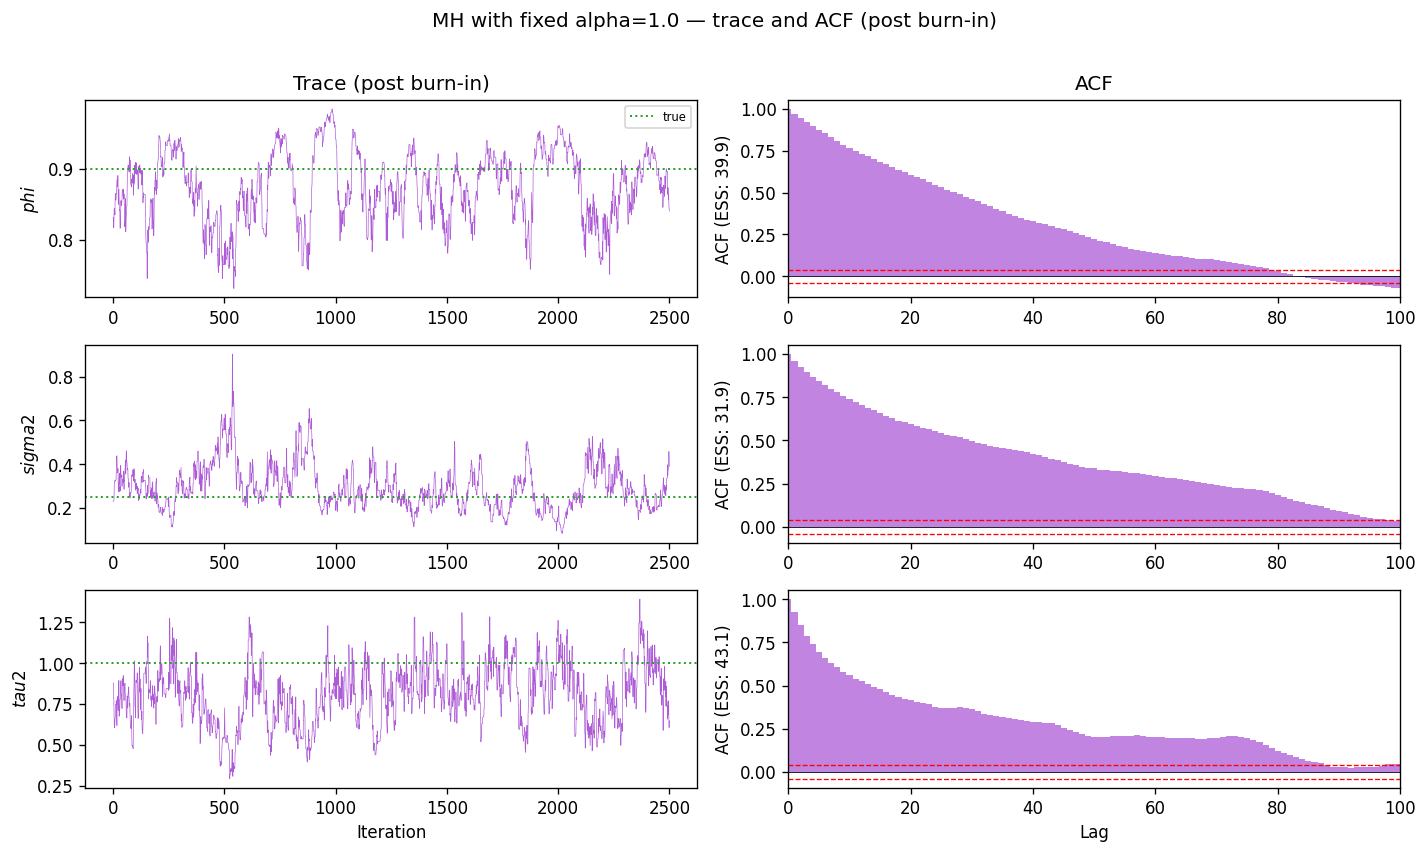

In [36]:
fig, axes = plt.subplots(3, 2, figsize=(12, 7))

for k, name in enumerate(names_fa):
    samp = constrained_fa[:, k]
    tv   = TRUE_PARAMS[name]

    ax_t = axes[k, 0]
    ax_t.plot(samp, lw=0.4, color='darkorchid', alpha=0.8)
    ax_t.axhline(tv, color='C2', ls=':', lw=1.2, label='true')
    ax_t.set_ylabel(f'${name}$')
    if k == 0:
        ax_t.set_title('Trace (post burn-in)')
        ax_t.legend(fontsize=7)

    ax_a = axes[k, 1]
    n_s     = len(samp)
    max_lag = min(100, n_s - 1)
    xc      = samp - samp.mean()
    var     = xc.var()
    acf     = np.correlate(xc, xc, mode='full')[n_s - 1:] / (var * n_s)
    ax_a.bar(np.arange(max_lag + 1), acf[:max_lag + 1],
             width=1.0, color='darkorchid', alpha=0.6)
    ax_a.axhline(0,  color='black', lw=0.5)
    ax_a.axhline( 1.96 / np.sqrt(n_s), color='red', ls='--', lw=0.8)
    ax_a.axhline(-1.96 / np.sqrt(n_s), color='red', ls='--', lw=0.8)
    ax_a.set_xlim(0, max_lag)
    ax_a.set_ylabel(f'ACF (ESS: {chain_ess(samp):.1f})') # Report ESS
    if k == 0:
        ax_a.set_title('ACF')

axes[-1, 0].set_xlabel('Iteration')
axes[-1, 1].set_xlabel('Lag')
plt.suptitle('MH with fixed alpha=1.0 — trace and ACF (post burn-in)', y=1.01)
plt.tight_layout()
plt.show()


### 4. Parameter Estimation with Nelder-Mead

In [37]:
# Nelder-Mead PMMLE with alpha fixed — same 3-param model.
# Uses particle-filter log-likelihood estimate; expect ~3 min runtime.

from estimation.nelder_mead import NelderMeadPMMLE

model_nm = FixedAlphaSSM(
    alpha_fixed=alpha_true,
    phi=phi_true, sigma2=sigma2_true, tau2=tau2_true,
    initial_var=initial_var_fixed, seed=SEED,
)

nm = NelderMeadPMMLE(
    model=model_nm,
    data=observations,
    N_particles_1=100,
    N_particles_2=300,
    n_restarts=3,
    restart_std=0.5,
    seed=0,
)
nm_result = nm.fit()
print(nm_result.summary())


Stage 1  N_particles=100, 3 restart(s)
  restart 1/3: loglik≈-340.16  nfev=125  converged
  restart 2/3: loglik≈-345.42  nfev=139  converged
  restart 3/3: loglik≈-341.15  nfev=154  converged

Stage 2  N_particles=300, starting from stage-1 best
  loglik≈-341.27  nfev=152  converged
NelderMeadPMMLE.fit  128.052s
PMMResult  loglik=-342.0694
  Stage 1: converged  n_evals=418
  Stage 2: converged  n_evals=152
  Optimization terminated successfully.

  Parameter             Estimate
  --------------------------------
  phi                   0.905936
  sigma2                0.228670
  tau2                  1.000096


### 5. Comparison Summary of Parameter Estimation Methods

In [38]:
# Comparison: True | MLE | MH | NM PMMLE
# MLE SE:        delta-method standard errors in constrained space
# MH std (adj):  posterior std scaled by sqrt(n/ESS) to reflect MCMC autocorrelation

names_est = list(model_mle.params_dict.keys())   # ['phi', 'sigma2', 'tau2']
mle_con   = list(mle_result.constrained_params)
nm_con    = list(nm_result.constrained_params)

# MH posterior summaries (post-burn-in)
mh_mean, mh_adj_std = [], []
for k in range(len(names_est)):
    samp = constrained_fa[:, k]
    ess  = chain_ess(samp)
    mh_mean.append(samp.mean())
    mh_adj_std.append(samp.std() * np.sqrt(len(samp) / ess) if ess > 0 else np.nan)

# ── print table ───────────────────────────────────────────────────────────────
w = [10, 8, 10, 9, 10, 12, 10]
header = (
    f"{'Param':<{w[0]}} {'True':>{w[1]}} {'MLE':>{w[2]}} {'MLE SE':>{w[3]}}"
    f" {'MH mean':>{w[4]}} {'MH std(adj)':>{w[5]}} {'NM PMMLE':>{w[6]}}"
)
print(header)
print("─" * len(header))

for k, name in enumerate(names_est):
    tv = TRUE_PARAMS[name]
    se = (f"{mle_result.std_errors[k]:>{w[3]}.4f}"
          if mle_result.std_errors is not None and not np.isnan(mle_result.std_errors[k])
          else f"{'—':>{w[3]}}")
    print(
        f"{name:<{w[0]}} {tv:>{w[1]}.4f} {mle_con[k]:>{w[2]}.4f} {se}"
        f" {mh_mean[k]:>{w[4]}.4f} {mh_adj_std[k]:>{w[5]}.4f} {nm_con[k]:>{w[6]}.4f}"
    )

print()
print(f"{'Log-likelihood':<22} {'KF (exact)':>12} {'MLE':>12} {'—':>12} {'NM PMMLE (PF)':>14}")
print("─" * 64)
print(f"{'':22} {kf_loglik:>12.2f} {mle_result.loglik:>12.2f} {'—':>12} {nm_result.loglik:>14.2f}")

Param          True        MLE    MLE SE    MH mean  MH std(adj)   NM PMMLE
───────────────────────────────────────────────────────────────────────────
phi          0.9000     0.8857    0.0466     0.8738       0.3892     0.9059
sigma2       0.2500     0.2510    0.0861     0.2953       0.8957     0.2287
tau2         1.0000     0.8651    0.1806     0.8068       1.3810     1.0001

Log-likelihood           KF (exact)          MLE            —  NM PMMLE (PF)
────────────────────────────────────────────────────────────────
                            -341.78      -341.28            —        -342.07


## Section IV. Estimation Extension MH
1. Effect of number of iterations for MH (check for convergence to true or MLE values)
2. Misspecified fixed alpha for MH (compared with MLE with misspecified alpha as well)
3. Hypothesis testing on estimated parameters. 

## Section V: Estimation Extension PMMH and BlockedPMMH
Parameter estimation using PMMH, alpha fixed to true value
N_particles = 1000
Iterations = 1000
Choose burn-in period
Results: estimated parameter values
Plot Chain, ACF

In [43]:
# ── setup: naive PMMH and Block PMMH, both with alpha fixed ──────────────────
# Block structure: dynamics (phi=0) and noise variances (sigma2=1, tau2=2).
BLOCKS      = [[0], [1, 2]]   # dynamics block, noise variance block
N_ITER_CMP  = 2000
N_PART_CMP  = 200
BURN_IN_CMP = 500

model_n = FixedAlphaSSM(alpha_fixed = alpha_true, phi=TRUE_PARAMS['phi'], sigma2=TRUE_PARAMS['sigma2'],
                         tau2=TRUE_PARAMS['tau2'], seed=1)
model_b = FixedAlphaSSM(alpha_fixed = alpha_true, phi=TRUE_PARAMS['phi'], sigma2=TRUE_PARAMS['sigma2'],
                         tau2=TRUE_PARAMS['tau2'], seed=2)

theta0_cmp = model_n.unconstrain_params(
    [TRUE_PARAMS['phi'], TRUE_PARAMS['sigma2'], TRUE_PARAMS['tau2']]
)
step_cmp = np.array([0.10, 0.15, 0.15])   # per-dim steps: (atanh φ, log σ², log τ²)

pf_n   = ParticleFilter(model_n, N_PART_CMP, observations, SystematicResampling(seed=1))
pmmh_n = PMMH(model_n, pf_n, n_iter=N_ITER_CMP,
              step_sizes=step_cmp, theta0=theta0_cmp,
              log_prior=log_prior_fixed_alpha, seed=10)

pf_b   = ParticleFilter(model_b, N_PART_CMP, observations, SystematicResampling(seed=2))
pmmh_b = BlockPMMH(model_b, pf_b, n_iter=N_ITER_CMP,
                   step_sizes=step_cmp, theta0=theta0_cmp,
                   log_prior=log_prior_fixed_alpha,
                   blocks=BLOCKS, seed=20)

print(repr(pmmh_n))
print(repr(pmmh_b))

PMMH(model=SimpleLinearGaussianSSM(phi=0.9, alpha=1.5, sigma2=0.25, tau2=1.0), n_iter=2000, N_particles=200)
BlockPMMH(model=SimpleLinearGaussianSSM(phi=0.9, alpha=1.5, sigma2=0.25, tau2=1.0), n_iter=2000, N_particles=200, n_blocks=2)


In [44]:
print("Running naive PMMH (alpha fixed=1.0) ...")
chain_n, ll_n, acc_n = pmmh_n.run()
print(f"  acceptance rate: {acc_n.mean():.3f}")

Running naive PMMH (alpha fixed=1.0) ...
[500/2000]  theta = [ 0.33983774 -0.3223777  -0.05916066],  loglik = -340.89,  accept rate = 0.298
[1000/2000]  theta = [ 0.68577583 -0.66027147 -0.11055464],  loglik = -343.51,  accept rate = 0.294
[1500/2000]  theta = [ 1.04760099 -1.00693902 -0.14331983],  loglik = -341.31,  accept rate = 0.300
PMMH.run  587.491s
  acceptance rate: 0.299


In [46]:
print("Running Block PMMH (alpha fixed=1.0) ...")
chain_b, ll_b, acc_b = pmmh_b.run()
print(f"  acceptance rate: {acc_b.mean():.3f}")

Running Block PMMH (alpha fixed=1.0) ...


KeyboardInterrupt: 

In [ ]:
constrained_n = model_n.constrain_chain(chain_n[BURN_IN_CMP:])
constrained_b = model_b.constrain_chain(chain_b[BURN_IN_CMP:])

In [47]:
names_cmp = list(model_n.params_dict.keys())
print(f"\n{'':8}  {'True':>8}  {'Naive mean':>12} {'Naive ESS':>8} {'Block mean':>12} {'Block ESS':>8}")
print("─" * 46)
for k, name in enumerate(names_cmp):
    naive_ess = chain_ess(constrained_n[:, k])
    block_ess = chain_ess(constrained_b[:,k])
    print(f"{name:<8}  {TRUE_PARAMS[name]:>8.4f}  "
          f"{constrained_n[:, k].mean():>12.4f}  "
          f"{naive_ess:>12.4f}  "
          f"{constrained_b[:, k].mean():>12.4f}  "
          f"{block_ess:>12.4f}")


              True    Naive mean Naive ESS   Block mean Block ESS
──────────────────────────────────────────────


NameError: name 'constrained_n' is not defined

In [ ]:
# ── trace plots and posterior comparison ──────────────────────────────────────
names_cmp = list(model_n.params_dict.keys())
fig, axes = plt.subplots(3, 3, figsize=(13, 8))

for k, name in enumerate(names_cmp):
    tv = TRUE_PARAMS[name]

    for col, (label, ch, color) in enumerate([
        ('Naive PMMH', constrained_n, 'steelblue'),
        ('Block PMMH', constrained_b, 'tomato'),
    ]):
        ax = axes[k, col]
        ax.plot(ch[:, k], lw=0.5, color=color, alpha=0.7)
        ax.axhline(tv, color='C2', ls=':', lw=1.2, label='true' if k == 0 else None)
        ax.set_ylabel(f'${name}$' if col == 0 else '')
        if k == 0:
            ax.set_title(label)
            ax.legend(fontsize=7)

    ax_m = axes[k, 2]
    lo = min(constrained_n[:, k].min(), constrained_b[:, k].min())
    hi = max(constrained_n[:, k].max(), constrained_b[:, k].max())
    bins = np.linspace(lo, hi, 40)
    for label, ch, color in [
        ('Naive PMMH', constrained_n, 'steelblue'),
        ('Block PMMH', constrained_b, 'tomato'),
    ]:
        ax_m.hist(ch[:, k], bins=bins, density=True, alpha=0.4, color=color, label=label)
    ax_m.axvline(tv, color='C2', ls=':', lw=1.5)
    ax_m.set_xlabel(f'${name}$')
    if k == 0:
        ax_m.set_title('Posterior marginals')
        ax_m.legend(fontsize=7)

for col in range(2):
    axes[-1, col].set_xlabel('iteration (post burn-in)')
plt.suptitle(
    f'Naive PMMH (acc={acc_n.mean():.2f}) vs Block PMMH (acc={acc_b.mean():.2f})'
    r' — $\alpha$ fixed',
    y=1.01, fontsize=10,
)
plt.tight_layout()
plt.show()


## Section VI: Regime Switching Model

1. Generate synthetic data
2. Show regime detection in rbpf filtering vs particle filter

SimpleRegimeSwitchingSSM
  1-D regime-switching linear Gaussian SSM
  Regimes: 2  (sigma2 is regime-specific; phi, alpha, tau2 shared)
  Transition:  x_t = 0.9 * x_{t-1} + eps_t,  eps_t ~ N(0, sigma2_{s_t})
  Observation: y_t = 1.0 * x_t + nu_t,  nu_t ~ N(0, 1.0)
  sigma2 per regime: [0.3, 1.5]
  Stationary var per regime: [1.5789, 7.8947]
  Stationary regime probs: [0.6, 0.4]
  Regime transition matrix:
[[0.9  0.1 ]
 [0.15 0.85]]

Regime counts:  Low-vol=118 (59%)  High-vol=82 (41%)


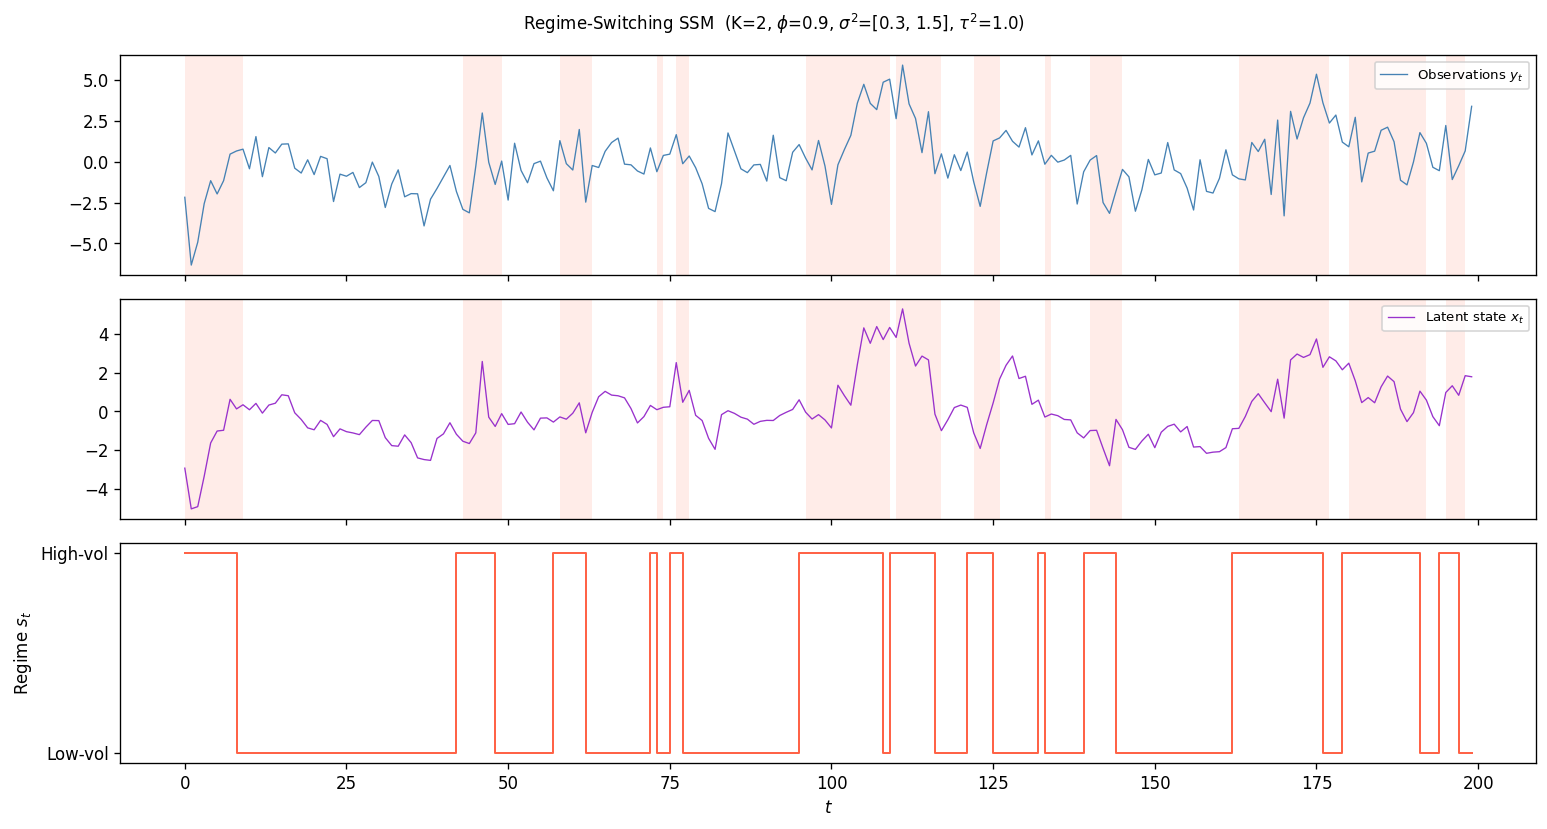

In [ ]:
# ── True parameters ──────────────────────────────────────────────────────────
K_RS    = 2
T_RS    = 200
SEED_RS = 42

phi_rs    = 0.90
alpha_rs  = 1.0                          # fixed for identifiability
sigma2_rs = np.array([0.30, 1.50])       # regime 0: quiet, regime 1: turbulent
tau2_rs   = 1.0
P_rs      = np.array([[0.90, 0.10],
                       [0.15, 0.85]])    # ~90% / ~85% within-regime persistence

TRUE_RS = {'phi': phi_rs, 'sigma2_0': sigma2_rs[0], 'sigma2_1': sigma2_rs[1], 'tau2': tau2_rs}

rs_model = SimpleRegimeSwitchingSSM(
    phi=phi_rs, alpha=alpha_rs,
    sigma2=sigma2_rs, tau2=tau2_rs,
    trans_matrix=P_rs, seed=SEED_RS,
)
print(rs_model.describe())

# ── Generate synthetic data ───────────────────────────────────────────────────
rs_states, rs_regimes, rs_obs = rs_model.generate_data(T_RS)

counts = np.bincount(rs_regimes, minlength=K_RS)
print(f"\nRegime counts:  Low-vol={counts[0]} ({100*counts[0]/T_RS:.0f}%)  "
      f"High-vol={counts[1]} ({100*counts[1]/T_RS:.0f}%)")

# ── Plot ──────────────────────────────────────────────────────────────────────
def regime_spans(regimes, target=1):
    spans, in_span = [], False
    for t, r in enumerate(regimes):
        if r == target and not in_span:
            start, in_span = t, True
        elif r != target and in_span:
            spans.append((start, t)); in_span = False
    if in_span:
        spans.append((start, len(regimes)))
    return spans

t_rs         = np.arange(T_RS)
high_vol_spans = regime_spans(rs_regimes, target=1)

fig, axes = plt.subplots(3, 1, figsize=(13, 7), sharex=True)

axes[0].plot(t_rs, rs_obs[:, 0],    lw=0.8, color='steelblue',  label='Observations $y_t$')
axes[1].plot(t_rs, rs_states[:, 0], lw=0.8, color='darkorchid', label='Latent state $x_t$')
axes[2].step(t_rs, rs_regimes, lw=1.2, color='tomato')
axes[2].set_yticks([0, 1]);  axes[2].set_yticklabels(['Low-vol', 'High-vol'])
axes[2].set_ylabel('Regime $s_t$')

for ax in axes[:2]:
    for s, e in high_vol_spans:
        ax.axvspan(s, e, alpha=0.12, color='tomato', lw=0)
    ax.legend(fontsize=8, loc='upper right')

axes[-1].set_xlabel('$t$')
fig.suptitle(
    rf'Regime-Switching SSM  (K={K_RS}, $\phi$={phi_rs}, '
    rf'$\sigma^2$={sigma2_rs.tolist()}, $\tau^2$={tau2_rs})',
    fontsize=10,
)
plt.tight_layout()
plt.show()


RaoBlackwellizedParticleFilter.run_filter  0.106s
RBPF log-likelihood: -363.67
RBPF RMSE (vs true state): 0.6461


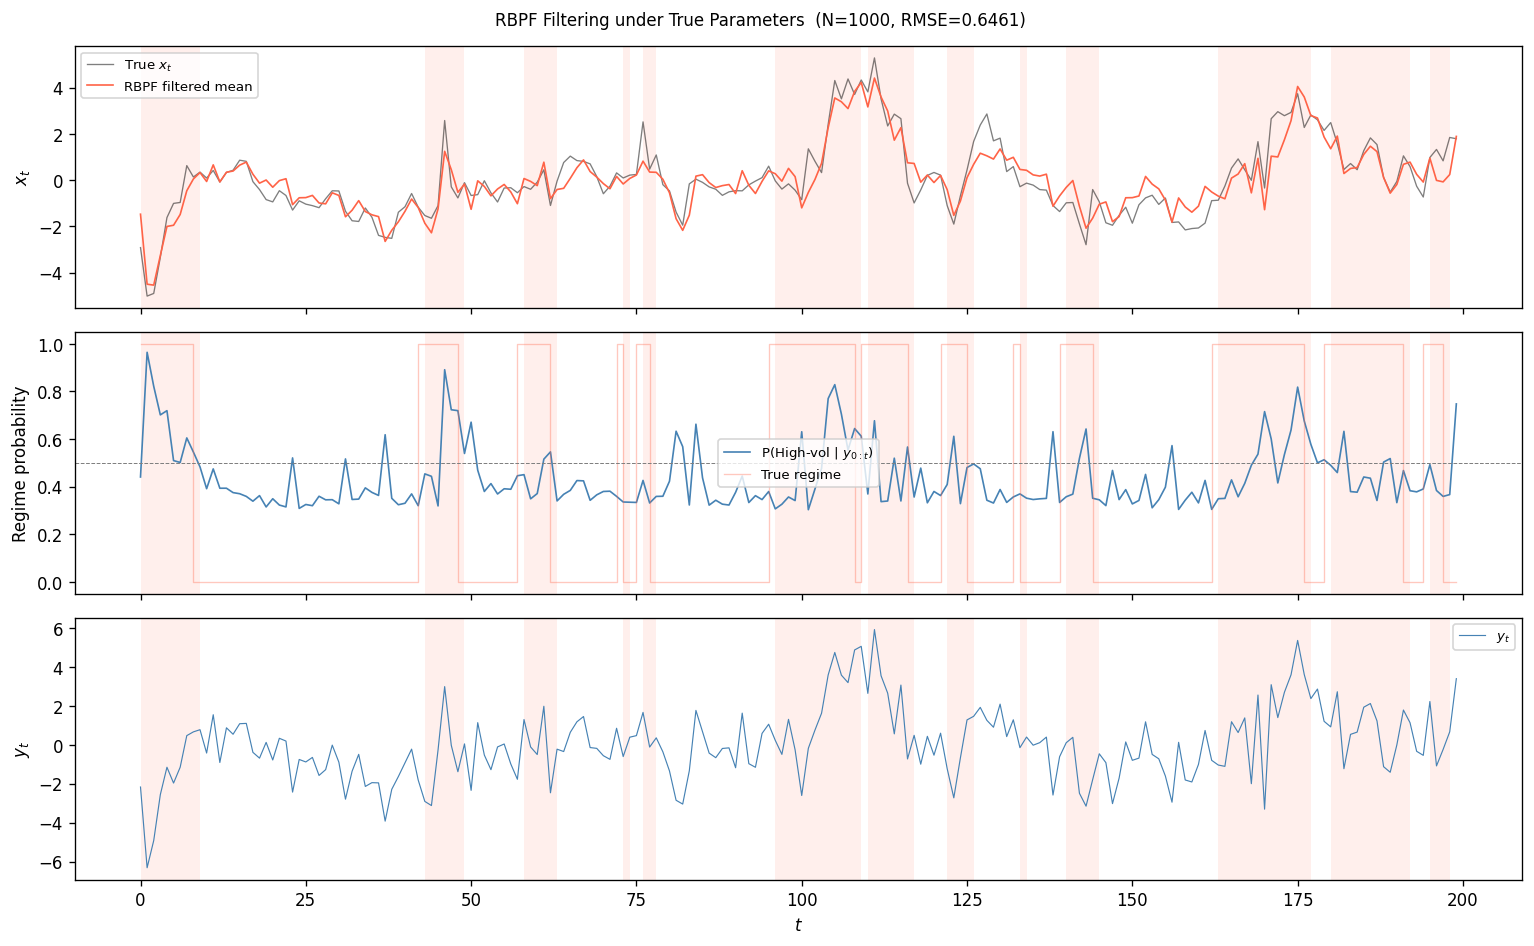

In [49]:
# ── Run RBPF ─────────────────────────────────────────────────────────────────
N_RBPF = 1000

rbpf = RaoBlackwellizedParticleFilter(
    model=rs_model,
    N_particles=N_RBPF,
    data=rs_obs,
    resample_method=SystematicResampling(seed=SEED_RS),
)
rbpf_states, _, _, _, rbpf_loglik = rbpf.run_filter()
rbpf_states       = rbpf_states[:, 0]
rbpf_regime_probs = rbpf.regime_prob_history   # (T, K)

rbpf_rmse = rmse(rs_states[:, 0], rbpf_states)
print(f"RBPF log-likelihood: {rbpf_loglik:.2f}")
print(f"RBPF RMSE (vs true state): {rbpf_rmse:.4f}")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(13, 8), sharex=True)

axes[0].plot(t_rs, rs_states[:, 0], lw=0.8, color='black', alpha=0.5, label='True $x_t$')
axes[0].plot(t_rs, rbpf_states,     lw=1.0, color='tomato',            label='RBPF filtered mean')
axes[0].set_ylabel('$x_t$');  axes[0].legend(fontsize=8)

axes[1].plot(t_rs, rbpf_regime_probs[:, 1], lw=1.0, color='steelblue',
             label='P(High-vol | $y_{0:t}$)')
axes[1].step(t_rs, rs_regimes, lw=0.8, color='tomato', alpha=0.35, label='True regime')
axes[1].axhline(0.5, color='grey', lw=0.6, ls='--')
axes[1].set_ylim(-0.05, 1.05);  axes[1].set_ylabel('Regime probability')
axes[1].legend(fontsize=8)

axes[2].plot(t_rs, rs_obs[:, 0], lw=0.7, color='steelblue', label='$y_t$')
axes[2].set_ylabel('$y_t$');  axes[2].legend(fontsize=8)

for ax in axes:
    for s, e in high_vol_spans:
        ax.axvspan(s, e, alpha=0.10, color='tomato', lw=0)

axes[-1].set_xlabel('$t$')
fig.suptitle(f'RBPF Filtering under True Parameters  (N={N_RBPF}, RMSE={rbpf_rmse:.4f})',
             fontsize=10)
plt.tight_layout()
plt.show()


## Section VII: Regime Switching Model Filtering using RBPF under true parameters

In [50]:
# ── Model for estimation (alpha fixed, estimates phi, sigma2_0, sigma2_1, tau2, P) ──
model_nm_rs = FixedAlphaRS(
    alpha_fixed=alpha_rs,
    phi=phi_rs, sigma2=sigma2_rs, tau2=tau2_rs,
    trans_matrix=P_rs, seed=SEED_RS,
)

# ── Two-stage Nelder-Mead RBPF-PMLE ──────────────────────────────────────────
# Stage 1: coarse search with fewer particles (N=150, 3 restarts)
# Stage 2: refinement with more particles (N=500) from the stage-1 best
nm_rs = NelderMeadPMMLE(
    model=model_nm_rs,
    data=rs_obs,
    N_particles_1=100,
    N_particles_2=300,
    filter_cls=RaoBlackwellizedParticleFilter,
    n_restarts=3,
    restart_std=0.4,
    seed=0,
)
print(nm_rs)

nm_rs_result = nm_rs.fit()
print()
print(nm_rs_result.summary())

# ── Comparison table: True vs RBPF-PMLE ──────────────────────────────────────
names_nm_rs = list(model_nm_rs.params_dict.keys())
nm_rs_con   = list(nm_rs_result.constrained_params)

print(f"\n{'Param':<12} {'True':>10} {'RBPF-PMLE':>12}")
print("─" * 38)
for k, name in enumerate(names_nm_rs):
    tv = TRUE_RS.get(name, float('nan'))
    print(f"{name:<12} {tv:>10.4f} {nm_rs_con[k]:>12.4f}")

print(f"\nLog-likelihood (RBPF estimate at optimum): {nm_rs_result.loglik:.2f}")


NelderMeadPMMLE(model=FixedAlphaRS(n_regimes=2, alpha_fixed=1.0, phi=0.9, sigma2=[0.3, 1.5], tau2=1.0), N1=100, N2=300, n_restarts=3)
Stage 1  N_particles=100, 3 restart(s)
RaoBlackwellizedParticleFilter.run_filter  0.036s
RaoBlackwellizedParticleFilter.run_filter  0.033s
RaoBlackwellizedParticleFilter.run_filter  0.032s
RaoBlackwellizedParticleFilter.run_filter  0.032s
RaoBlackwellizedParticleFilter.run_filter  0.032s
RaoBlackwellizedParticleFilter.run_filter  0.033s
RaoBlackwellizedParticleFilter.run_filter  0.034s
RaoBlackwellizedParticleFilter.run_filter  0.034s
RaoBlackwellizedParticleFilter.run_filter  0.033s
RaoBlackwellizedParticleFilter.run_filter  0.036s
RaoBlackwellizedParticleFilter.run_filter  0.032s
RaoBlackwellizedParticleFilter.run_filter  0.034s
RaoBlackwellizedParticleFilter.run_filter  0.044s
RaoBlackwellizedParticleFilter.run_filter  0.047s
RaoBlackwellizedParticleFilter.run_filter  0.038s
RaoBlackwellizedParticleFilter.run_filter  0.036s
RaoBlackwellizedParticleFil

In [ ]:
# ── FixedAlphaRS: alpha fixed, estimates (phi, sigma2_0, sigma2_1, tau2, P) ──
# Flat layout: [phi, sigma2_0, sigma2_1, tau2, P_00, P_01, P_10, P_11]

from models.regime_switching_simple import FixedAlphaRS

# ── Setup ─────────────────────────────────────────────────────────────────────
N_ITER_RS  = 2000
BURN_IN_RS = 500
N_PART_RS  = 500

model_rs_est = FixedAlphaRS(
    alpha_fixed=alpha_rs,
    phi=phi_rs, sigma2=sigma2_rs, tau2=tau2_rs,
    trans_matrix=P_rs, seed=1,
)

def log_prior_rs(theta_con):
    K      = K_RS
    phi    = theta_con[0]
    sigma2 = np.array(theta_con[1:1 + K])   # must be array for np.any()
    tau2   = theta_con[1 + K]
    P      = np.array(theta_con[2 + K:]).reshape(K, K)

    if abs(phi) >= 1 or np.any(sigma2 <= 0) or tau2 <= 0:
        return -np.inf

    lp  = np.log(2) - np.log(1 + phi ** 2)           # Cauchy on phi
    lp += np.sum(-np.log(sigma2))                      # HalfCauchy on sigma2_k
    lp += -np.log(tau2)                               # HalfCauchy on tau2
    lp += sum((2 - 1) * np.log(np.clip(P[i], 1e-300, None)).sum()
              for i in range(K))                       # Dirichlet(2,2) on P rows
    return lp

theta0_rs = model_rs_est.unconstrain_params(
    [phi_rs] + sigma2_rs.tolist() + [tau2_rs] + P_rs.ravel().tolist()
)
# step sizes: [phi, log_sigma2_0, log_sigma2_1, log_tau2, log_P flat]
step_rs = np.array([0.05, 0.12, 0.12, 0.12, 0.15, 0.15, 0.15, 0.15])

rbpf_est = RaoBlackwellizedParticleFilter(
    model=model_rs_est,
    N_particles=N_PART_RS,
    data=rs_obs,
    resample_method=SystematicResampling(seed=1),
)
pmmh_rs = PMMH(
    model_rs_est, rbpf_est,
    n_iter=N_ITER_RS,
    step_sizes=step_rs,
    theta0=theta0_rs,
    log_prior=log_prior_rs,
    seed=10,
)
print(pmmh_rs)

# ── Run ───────────────────────────────────────────────────────────────────────
print(f"\nRunning RBPF-PMMH ({N_ITER_RS} iterations, N_particles={N_PART_RS}) ...")
chain_rs, ll_rs, acc_rs = pmmh_rs.run()
constrained_rs = model_rs_est.constrain_chain(chain_rs[BURN_IN_RS:])
print(f"Acceptance rate: {acc_rs.mean():.3f}")

# ── Summary table ─────────────────────────────────────────────────────────────
names_rs = list(model_rs_est.params_dict.keys())   # phi, sigma2_0, sigma2_1, tau2
print(f"\n{'Param':<12} {'True':>8} {'Post mean':>10} {'Post std':>10} {'ESS':>8}")
print("─" * 52)
for k, name in enumerate(names_rs):
    samp = constrained_rs[:, k]
    ess  = chain_ess(samp)
    print(f"{name:<12} {TRUE_RS.get(name, float('nan')):>8.4f} "
          f"{samp.mean():>10.4f} {samp.std():>10.4f} {ess:>8.1f}")

# ── Trace and posterior plots ─────────────────────────────────────────────────
fig, axes = plt.subplots(len(names_rs), 2, figsize=(12, 3 * len(names_rs)))

for k, name in enumerate(names_rs):
    samp = constrained_rs[:, k]
    tv   = TRUE_RS.get(name)

    axes[k, 0].plot(samp, lw=0.4, color='steelblue', alpha=0.8)
    if tv is not None:
        axes[k, 0].axhline(tv, color='tomato', ls='--', lw=1.2, label='true')
        axes[k, 0].legend(fontsize=7)
    axes[k, 0].set_ylabel(f'${name}$')
    if k == 0:
        axes[k, 0].set_title('Trace (post burn-in)')

    axes[k, 1].hist(samp, bins=40, density=True, color='steelblue', alpha=0.6)
    if tv is not None:
        axes[k, 1].axvline(tv, color='tomato', ls='--', lw=1.5, label='true')
        axes[k, 1].legend(fontsize=7)
    axes[k, 1].set_xlabel(f'${name}$')
    if k == 0:
        axes[k, 1].set_title('Posterior marginal')

axes[-1, 0].set_xlabel('Iteration (post burn-in)')
fig.suptitle(
    f'RBPF-PMMH  (N={N_PART_RS}, acc={acc_rs.mean():.2f}, '
    f'α fixed={alpha_rs})',
    y=1.01, fontsize=10,
)
plt.tight_layout()
plt.show()


PMMH(model=FixedAlphaRS(n_regimes=2, alpha_fixed=1.0, phi=0.9, sigma2=[0.3, 1.5], tau2=1.0), n_iter=2000, N_particles=500)

Running RBPF-PMMH (2000 iterations, N_particles=500) ...
[500/2000]  theta = [ 0.30016096 -0.58635901  0.18093038  0.00529785 -0.02558215 -0.16367017
 -0.19530548 -0.03310218],  loglik = -364.65,  accept rate = 0.586
[1000/2000]  theta = [ 0.59590847 -0.90702881  0.34711297 -0.03947269 -0.04952253 -0.3152447
 -0.39398894 -0.05067031],  loglik = -363.32,  accept rate = 0.572


## Section IX: Other Extensions
1. Model misspecification: Gaussian estimator on data generated by t model
2. Model misspecification: Gaussian estimatior on data generated by ARMA model 